# Credit Card Fraud Anomaly Detection

## tl;dr

Local Outlier Factor produced **0.176 test PR-AUC** and **0.913 ROC-AUC**. A threshold calibrated to flag 0.5% of validation transactions flagged 0.30% of the future test period and captured **52.0% of frauds** at **22.9% precision**. Reviewing exactly the top 0.5% of test scores captures **65.3% of frauds**.

## Context & Methods

The goal is to rank unusual transactions for limited human review. Isolation Forest and Local Outlier Factor are fit only on known-normal rows from the earliest 60% of transactions. The next 20% selects the model and calibrates a score threshold; the latest 20% is untouched until final evaluation.

### Key Assumptions

- `Time` order approximates deployment order within the two-day sample.
- Known genuine training rows are suitable examples of normal activity.
- The 0.5% validation alert-rate target is illustrative, not an actual bank capacity.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
env = os.environ.copy(); env['PYTHONPATH'] = str(ROOT / 'src')
if not (ROOT / 'data/raw/creditcard.csv').exists():
    subprocess.run([sys.executable, str(ROOT / 'scripts/download_data.py')], cwd=ROOT, check=True)
subprocess.run([sys.executable, str(ROOT / 'scripts/run_analysis.py')], cwd=ROOT, env=env, check=True, capture_output=True)
summary = json.loads((ROOT / 'reports/summary.json').read_text())
summary

{'rows': 284807,
 'frauds': 492,
 'fraud_rate': 0.001727485630620034,
 'split': {'train_rows': 170884, 'validation_rows': 56961, 'test_rows': 56962},
 'training_strategy': 'Models fit only on known-normal transactions from the earliest 60% of time-ordered data.',
 'alert_rate_target': 0.005,
 'selected_model': 'Local Outlier Factor',
 'selection_metric': 'validation PR-AUC',
 'test_pr_auc': 0.17562274252367607,
 'test_roc_auc': 0.9128208553799638,
 'test_alerts': 170,
 'test_actual_alert_rate': 0.002984445770864787,
 'test_frauds': 75,
 'test_frauds_captured': 39,
 'test_precision_at_alert_rate': 0.22941176470588234,
 'test_recall_at_alert_rate': 0.52,
 'test_false_positives': 131,
 'caveat': 'This anonymized two-day 2013 sample is a methods benchmark, not production fraud evidence.'}

## Data

The ULB/Worldline benchmark contains 284,807 transactions and only 492 frauds. The extreme imbalance makes ordinary accuracy uninformative.

In [2]:
data = pd.read_csv(ROOT / 'data/raw/creditcard.csv')
pd.DataFrame({'transactions': [len(data)], 'frauds': [int(data.Class.sum())], 'fraud_rate': [data.Class.mean()], 'missing_cells': [int(data.isna().sum().sum())]})

,transactions,frauds,fraud_rate,missing_cells
0,284807,492,0.001727,0


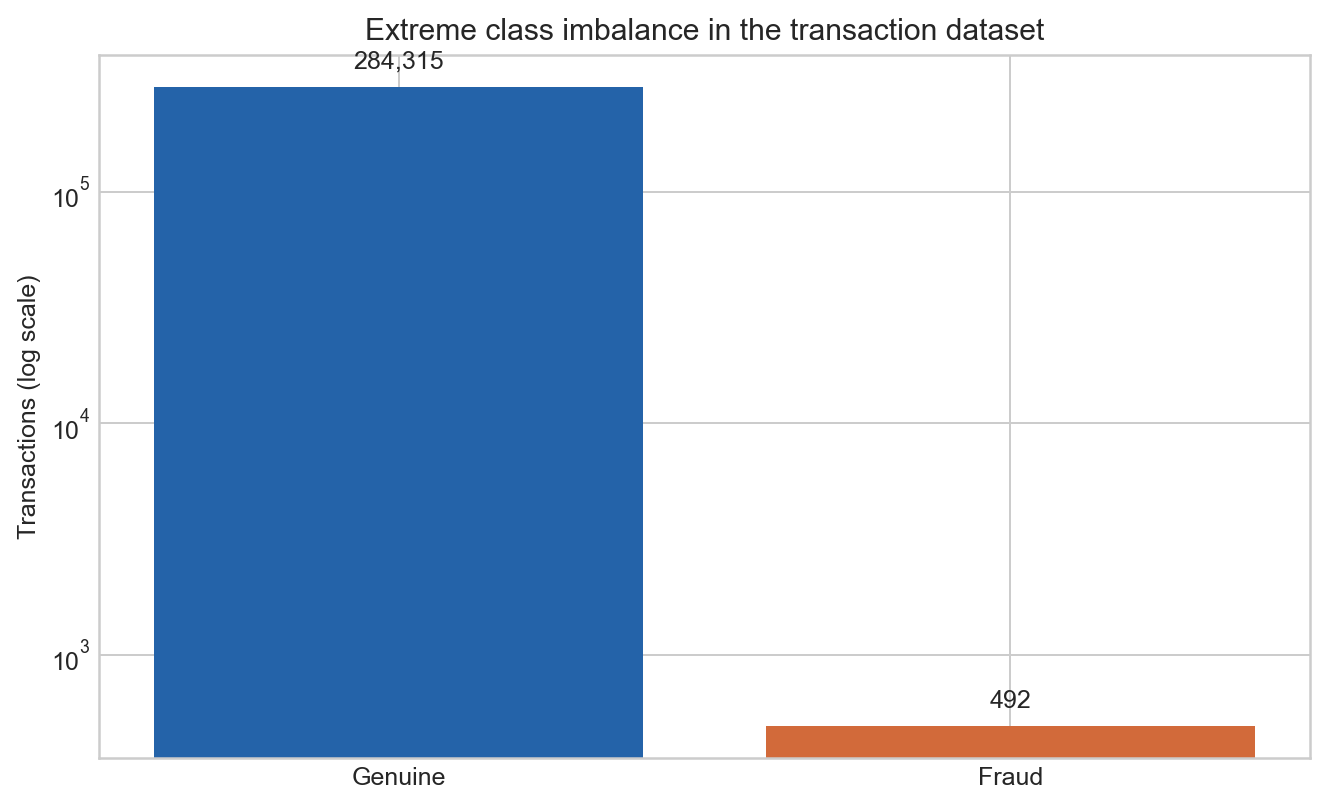

In [3]:
display(Image(filename=ROOT / 'reports/figures/class_imbalance.png', width=750))

## Results

### Ranking performance

PR-AUC is emphasized because it reflects the precision–recall tradeoff on the rare fraud class. The test no-skill baseline is its fraud prevalence.

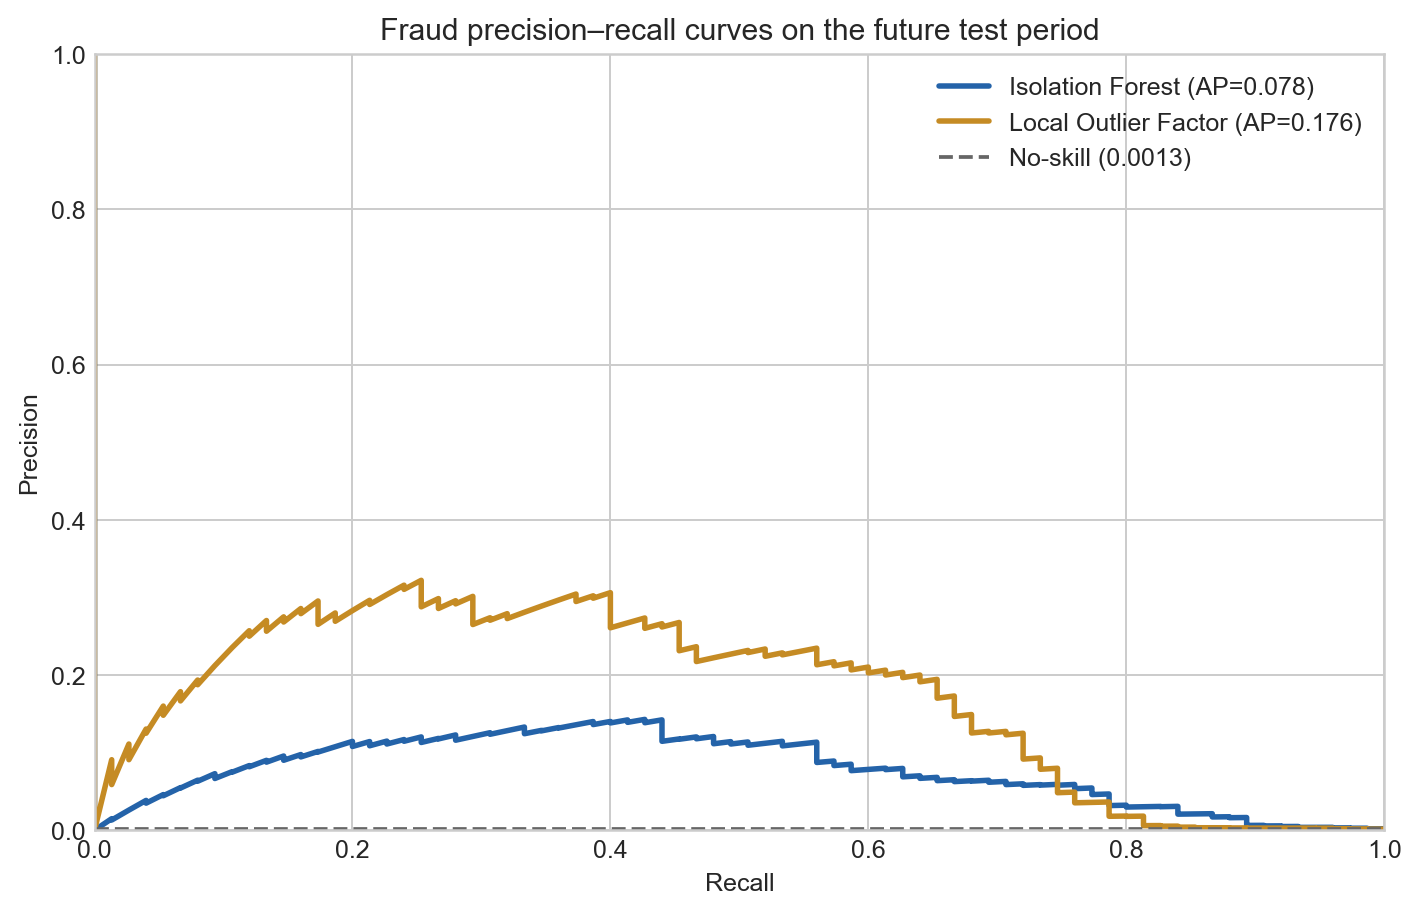

,transactions,frauds,alerts,frauds_captured,alert_rate,pr_auc,roc_auc,precision,recall,false_positives,model,threshold_from_validation
0,56962,75,170,39,0.0030,0.1756,0.9128,0.2294,0.5200,131,Local Outlier Factor,1.2368
1,56962,75,191,25,0.0034,0.0776,0.9517,0.1309,0.3333,166,Isolation Forest,0.0830


In [4]:
display(Image(filename=ROOT / 'reports/figures/precision_recall_curves.png', width=800))
pd.read_csv(ROOT / 'reports/test_metrics.csv').round(4)

### Validation-calibrated operating point

The score distribution shifted: thresholds intended to flag 0.5% of validation transactions flagged only 0.30–0.34% of test transactions. This is a monitoring signal, not an implementation detail to hide.

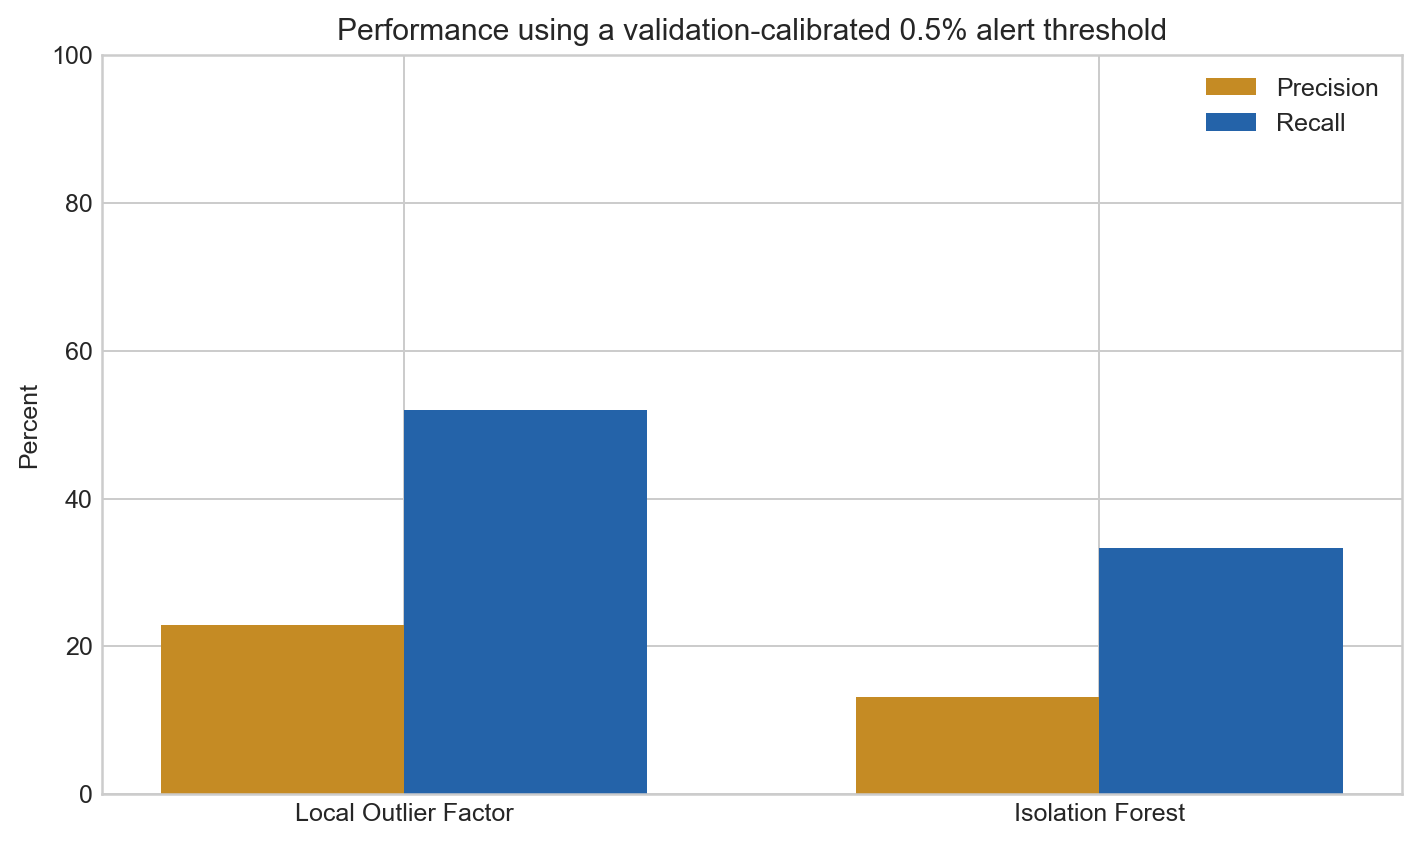

,transactions,frauds,alerts,frauds_captured,alert_rate,pr_auc,roc_auc,precision,recall,false_positives,model
0,56961,57,285,29,0.005,0.0750,0.9233,0.1018,0.5088,256,Local Outlier Factor
1,56961,57,285,13,0.005,0.0353,0.9422,0.0456,0.2281,272,Isolation Forest


In [5]:
display(Image(filename=ROOT / 'reports/figures/operating_point_comparison.png', width=800))
pd.read_csv(ROOT / 'reports/validation_metrics.csv').round(4)

### Analyst review capacity

The curve ranks the future test batch and asks what fraction of confirmed fraud would be captured at fixed review capacities.

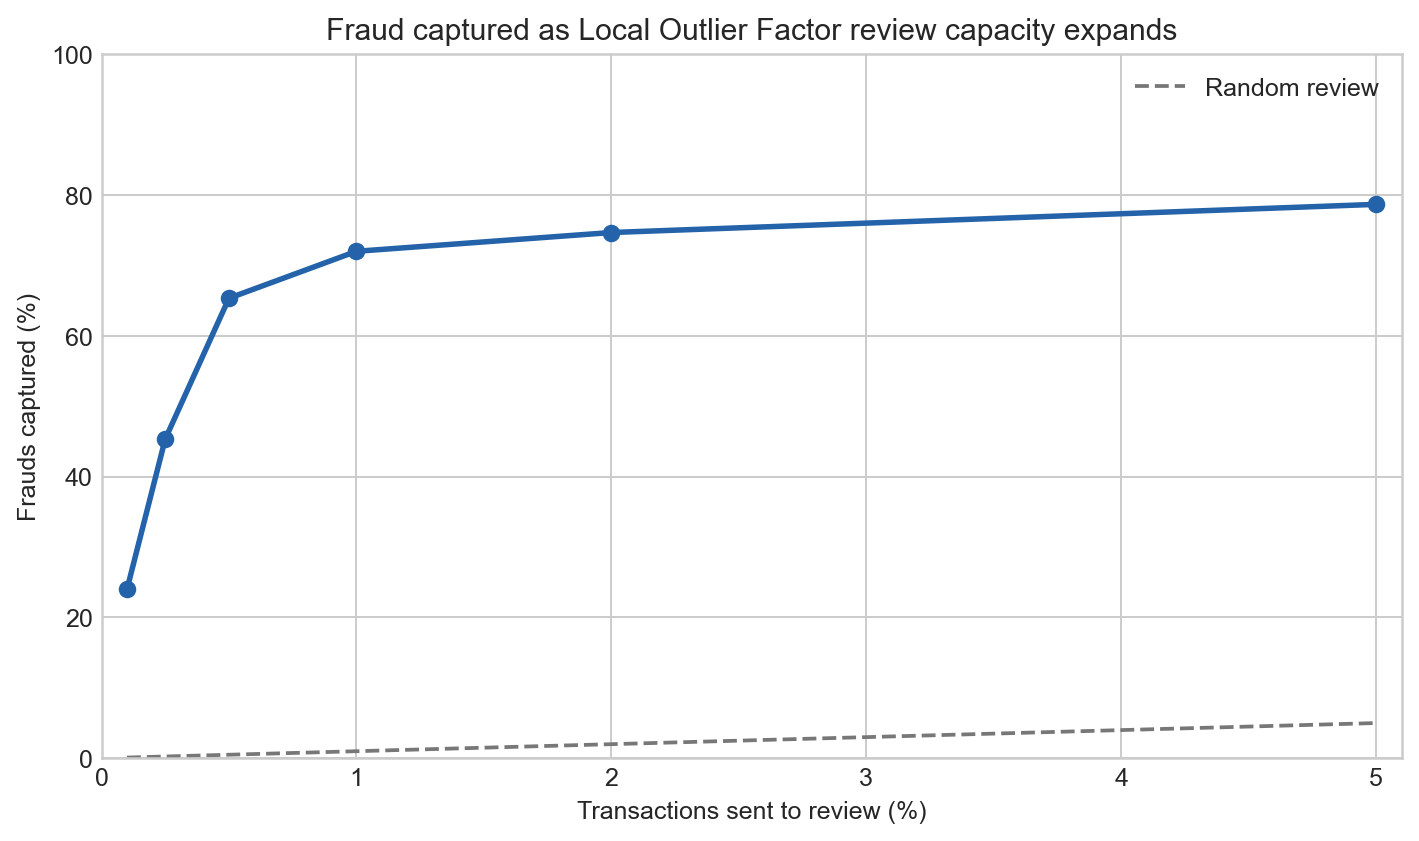

,review_rate,alerts,frauds_captured,recall,precision
0,0.10,57,18,24.00,31.58
1,0.25,143,34,45.33,23.78
2,0.50,285,49,65.33,17.19
3,1.00,570,54,72.00,9.47
4,2.00,1140,56,74.67,4.91
5,5.00,2849,59,78.67,2.07


In [6]:
display(Image(filename=ROOT / 'reports/figures/review_capacity_curve.png', width=800))
pd.read_csv(ROOT / 'reports/review_capacity_curve.csv').assign(review_rate=lambda d: d.review_rate * 100, recall=lambda d: d.recall * 100, precision=lambda d: d.precision * 100).round(2)

## Takeaways

- Use anomaly scores to prioritize review, not automatically block transactions.
- At an exact 0.5% batch review capacity, Local Outlier Factor captures 49 of 75 future-period frauds.
- Threshold transport changed alert volume, so production monitoring must track score drift and review load.
- Real deployment needs recent features, delayed labels, cost-sensitive decisions, explanations, and analyst feedback.
- Source: [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).